In [125]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas
from scipy.signal import find_peaks


In [2]:
filepath = r"MRG_MultiFreq_Stim_50_1000Hz.h5"

<KeysViewHDF5 ['Frequency_050Hz', 'Frequency_1000Hz', 'Frequency_100Hz', 'Frequency_150Hz', 'Frequency_200Hz', 'Frequency_250Hz', 'Frequency_300Hz', 'Frequency_350Hz', 'Frequency_400Hz', 'Frequency_450Hz', 'Frequency_500Hz', 'Frequency_550Hz', 'Frequency_600Hz', 'Frequency_650Hz', 'Frequency_700Hz', 'Frequency_750Hz', 'Frequency_800Hz', 'Frequency_850Hz', 'Frequency_900Hz', 'Frequency_950Hz', 'ModelParams']>
<KeysViewHDF5 ['Traces', 'time']>
<KeysViewHDF5 ['after_branch_daughter', 'after_branch_main', 'before_branch', 'branch_point', 'stimulation_point']>
<KeysViewHDF5 ['branch_nodes', 'branches_num', 'celsius', 'diam_scale', 'dt_ms', 'fiber_diameter_um', 'h_stop', 'nodes_dist', 'parent_axon_nodes']>
0.05
5010.0
21
Статистика интервалов между спайками:
--------------------------------------------------
After Branch Daughter:
  Количество интервалов: 1752
  Средний ISI: 2.857 ms
  Стандартное отклонение: 0.039 ms
  Минимальный ISI: 2.800 ms
  Максимальный ISI: 2.975 ms
  Коэффициент вар

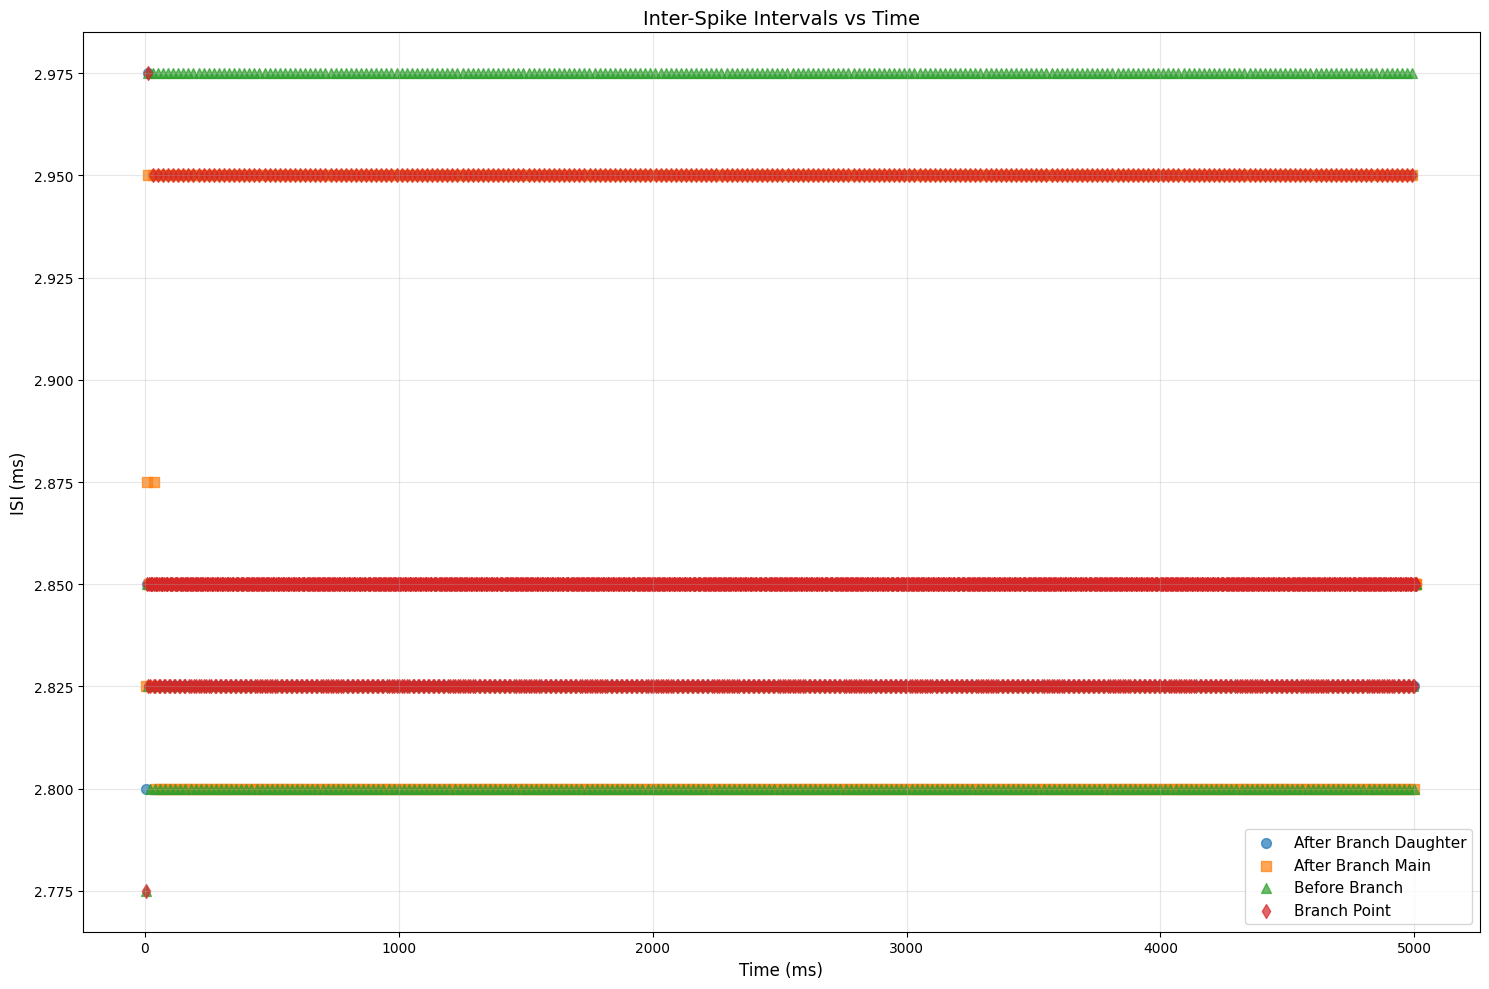

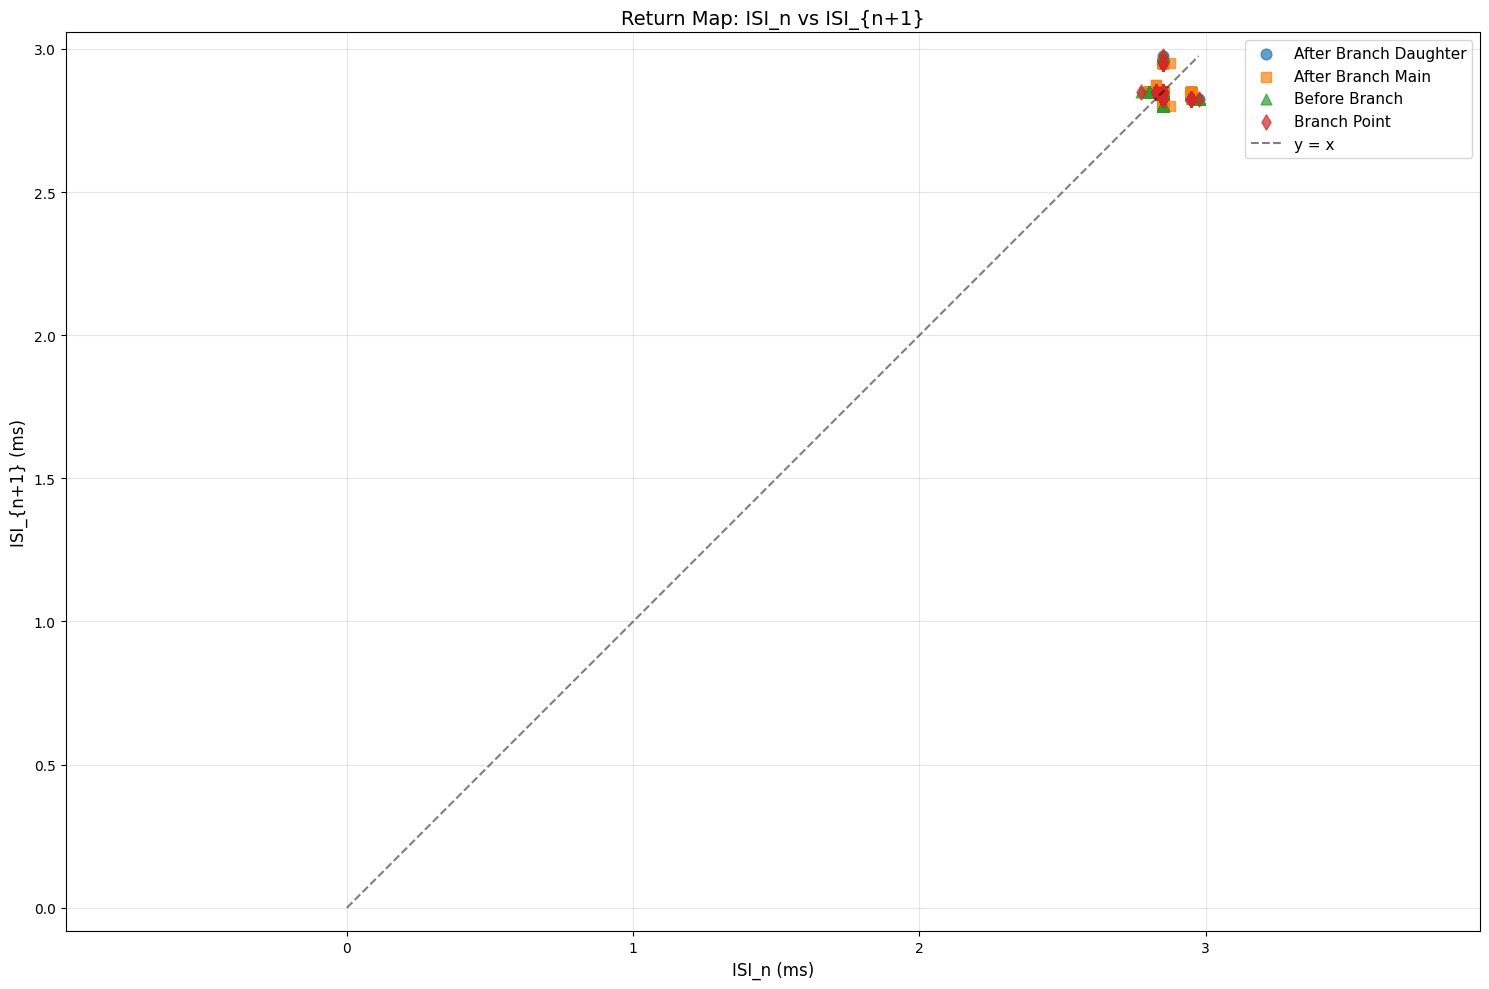

In [136]:
with h5py.File(filepath,'r') as f:
    print(f.keys())
    print(f["Frequency_1000Hz/Model"].keys())
    print(f["Frequency_1000Hz/Model/Traces"].keys())
    print(f["ModelParams"].attrs.keys())
    print(f["ModelParams"].attrs["dt_ms"])
    print(f["ModelParams"].attrs["h_stop"])
    print(f["ModelParams"].attrs["branch_nodes"])

    time_trace = f["Frequency_1000Hz/Model/time"][:]
    current_frequency = f["Frequency_700Hz/Model/Traces"]

    # Извлекаем трассы
    after_branch_daughter = current_frequency["after_branch_daughter"]
    after_branch_main = current_frequency["after_branch_main"]
    before_branch = current_frequency["before_branch"]
    branch_point = current_frequency["branch_point"]
    stim_point = current_frequency["stimulation_point"]

    # Получаем первые (и, вероятно, единственные) датасеты в каждой группе
    abd_trace = list(after_branch_daughter.values())[0][:]
    abm_trace = list(after_branch_main.values())[0][:]
    bb_trace = list(before_branch.values())[0][:]
    bp_trace = list(branch_point.values())[0][:]
    sp_trace = list(stim_point.values())[0][:]

    # Ищем пики для каждой трассы отдельно
    abd_peaks, _ = find_peaks(abd_trace, distance=50, height=np.max(abd_trace) - 10)
    abm_peaks, _ = find_peaks(abm_trace, distance=50, height=np.max(abm_trace) - 10)
    bb_peaks, _ = find_peaks(bb_trace, distance=50, height=np.max(bb_trace) - 10)
    bp_peaks, _ = find_peaks(bp_trace, distance=50, height=np.max(bp_trace) - 10)

    # Вычисляем интервалы между пиками (ISI - Inter-Spike Interval)
    abd_isi = np.diff(time_trace[abd_peaks])
    abm_isi = np.diff(time_trace[abm_peaks])
    bb_isi = np.diff(time_trace[bb_peaks])
    bp_isi = np.diff(time_trace[bp_peaks])

    # Вычисляем временные метки середины интервалов (необязательно, но полезно)
    abd_times = (time_trace[abd_peaks[:-1]] + time_trace[abd_peaks[1:]]) / 2
    abm_times = (time_trace[abm_peaks[:-1]] + time_trace[abm_peaks[1:]]) / 2
    bb_times = (time_trace[bb_peaks[:-1]] + time_trace[bb_peaks[1:]]) / 2
    bp_times = (time_trace[bp_peaks[:-1]] + time_trace[bp_peaks[1:]]) / 2

    # 1. Точечный график интервалов во времени
    plt.figure(figsize=(15, 10))

    plt.scatter(abd_times, abd_isi, s=50, alpha=0.7, label='After Branch Daughter', marker='o')
    plt.scatter(abm_times, abm_isi, s=50, alpha=0.7, label='After Branch Main', marker='s')
    plt.scatter(bb_times, bb_isi, s=50, alpha=0.7, label='Before Branch', marker='^')
    plt.scatter(bp_times, bp_isi, s=50, alpha=0.7, label='Branch Point', marker='d')

    plt.xlabel('Time (ms)', fontsize=12)
    plt.ylabel('ISI (ms)', fontsize=12)
    plt.title('Inter-Spike Intervals vs Time', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # 2. График ISIn vs ISIn+1 (return map)
    plt.figure(figsize=(15, 10))

    # Для каждого набора ISI создаем пары (ISI_n, ISI_{n+1})
    if len(abd_isi) > 1:
        plt.scatter(abd_isi[:-1], abd_isi[1:], s=60, alpha=0.7,
                   label='After Branch Daughter', marker='o')
    if len(abm_isi) > 1:
        plt.scatter(abm_isi[:-1], abm_isi[1:], s=60, alpha=0.7,
                   label='After Branch Main', marker='s')
    if len(bb_isi) > 1:
        plt.scatter(bb_isi[:-1], bb_isi[1:], s=60, alpha=0.7,
                   label='Before Branch', marker='^')
    if len(bp_isi) > 1:
        plt.scatter(bp_isi[:-1], bp_isi[1:], s=60, alpha=0.7,
                   label='Branch Point', marker='d')

    # Добавляем линию y=x для сравнения
    max_isi = max(np.max(abd_isi) if len(abd_isi) > 0 else 0,
                  np.max(abm_isi) if len(abm_isi) > 0 else 0,
                  np.max(bb_isi) if len(bb_isi) > 0 else 0,
                  np.max(bp_isi) if len(bp_isi) > 0 else 0)

    plt.plot([0, max_isi], [0, max_isi], 'k--', alpha=0.5, label='y = x')

    plt.xlabel('ISI_n (ms)', fontsize=12)
    plt.ylabel('ISI_{n+1} (ms)', fontsize=12)
    plt.title('Return Map: ISI_n vs ISI_{n+1}', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()

    # 4. Статистика ISI для каждого канала
    print("Статистика интервалов между спайками:")
    print("-" * 50)

    for name, isi in [('After Branch Daughter', abd_isi),
                      ('After Branch Main', abm_isi),
                      ('Before Branch', bb_isi),
                      ('Branch Point', bp_isi)]:
        if len(isi) > 0:
            print(f"{name}:")
            print(f"  Количество интервалов: {len(isi)}")
            print(f"  Средний ISI: {np.mean(isi):.3f} ms")
            print(f"  Стандартное отклонение: {np.std(isi):.3f} ms")
            print(f"  Минимальный ISI: {np.min(isi):.3f} ms")
            print(f"  Максимальный ISI: {np.max(isi):.3f} ms")
            print(f"  Коэффициент вариации: {np.std(isi)/np.mean(isi):.3f}")
            print()

In [64]:
print(np.mean(abm_trace))
print(np.max(abm_trace) - 10)

-66.45606756920122
-20.0166254415332


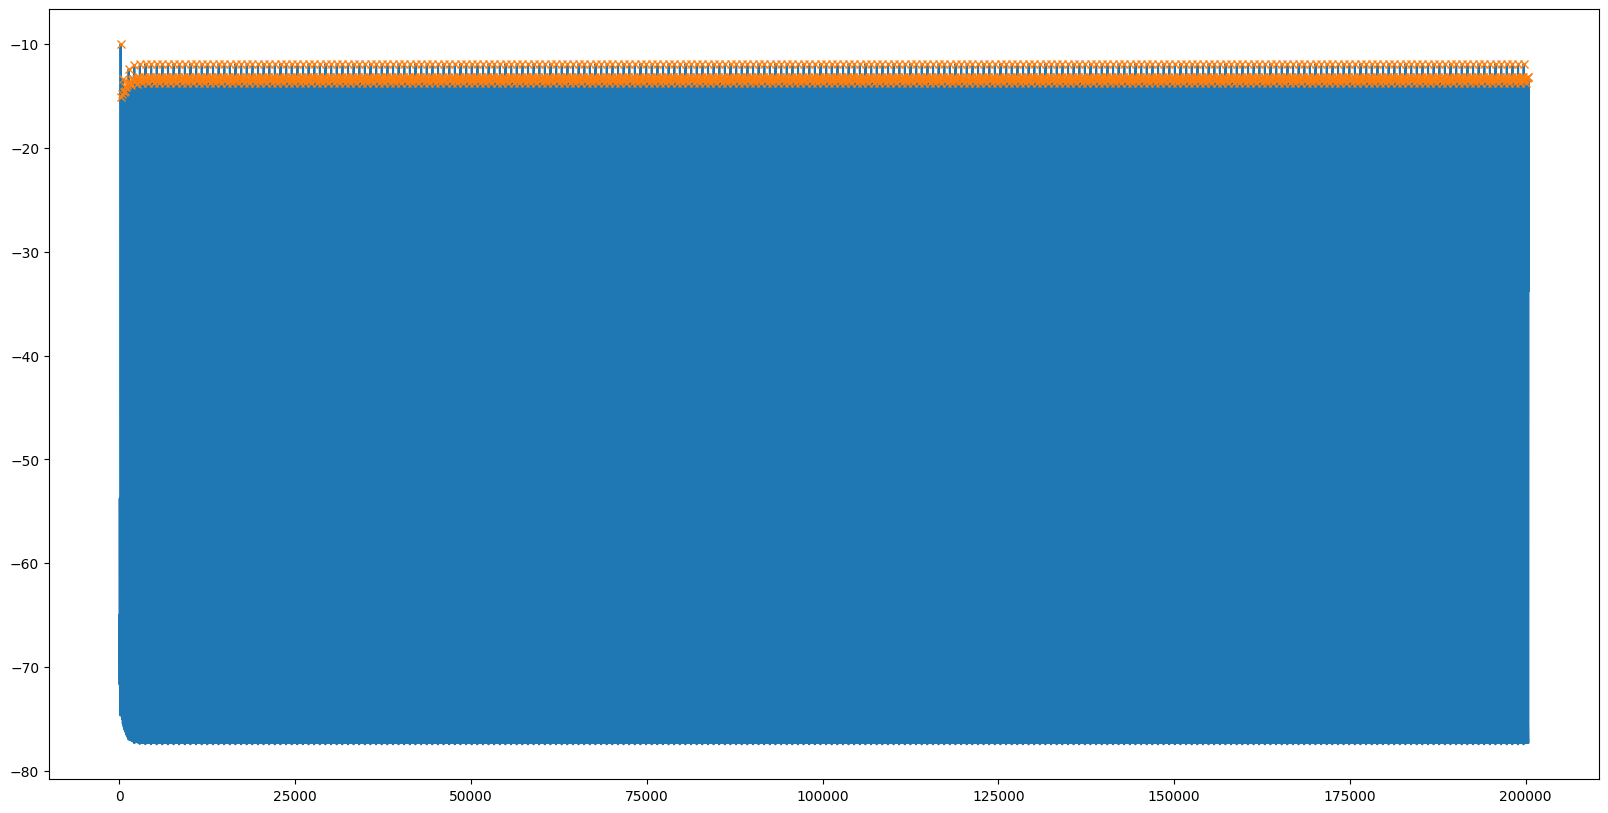

In [138]:
peaks, _ = find_peaks(abm_trace, distance=50, height=np.max(abm_trace) - 10)
plt.figure(figsize=(20,10))
plt.plot(abm_trace)
plt.plot(peaks, abm_trace[peaks], "x")
#plt.xlim(0,10000)


In [71]:
print(len(peaks))
print(peaks)
np.diff(peaks * dt_ms)

1753
[   165    278    393 ... 200166 200280 200394]


array([113, 115, 118, ..., 114, 114, 114], shape=(1752,))

In [108]:
print(len(abm_trace))

200401


In [111]:
print(len(time_trace) * 0.05 // 2)

5010.0


In [119]:
5010 // 0.005

1001999.0

In [120]:
200401 * 0.005

1002.005